# ECE 5510: Multiprocessor Programming Project: Concurrent Neural Signal Processor for Spindle Detection
## Submitted by Apurv Sanjay Deshpande (apurvsd@vt.edu) and Hari Makarand Sumant (harisumant@vt.edu) 
 

##  This python notebook contains the necessary Exploratory Data Analysis of the two datasets that we are using, and data preprocessing 
## Purpose of this file : to gain insights about the data, and go through the datasets and finally merge them for next stages

In [3]:
# Import the necessary libraries 
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [4]:
# Load the datasets
file_1 = 'datasets/extrait_wSleepPage01.csv'
file_2 = 'datasets/spindles.csv'

In [5]:
# Function to clean numerical columns by replacing commas and converting to float
def clean_numeric_columns(df, columns):
    for col in columns:
        # Replace commas with periods and convert to float
        df[col] = df[col].str.replace(',', '.').astype(float, errors='ignore')
    return df

In [6]:
# Reparse Dataset 1
dataset1 = pd.read_csv(file_1, delimiter=';', engine='python')
numeric_cols_dataset1 = ["SS" , "EOG Left", "EEG C3-A1", "EEG O1-A1", "EEG C4-A1", "EEG O2-A1"]
df1 = clean_numeric_columns(dataset1, numeric_cols_dataset1)

In [7]:
df1.head()

,Date,HH,MM,SS,EOG Left,EEG C3-A1,EEG O1-A1,EEG C4-A1,EEG O2-A1
0,08/03/2016,1,27,22.000,7.812500e-01,5.566406,-12.402344,0.976562,13.769531
1,08/03/2016,1,27,22.005,1.953125e+00,4.785156,-11.230469,-0.097656,17.089844
2,08/03/2016,1,27,22.010,-1.670000e-14,4.296875,-11.230469,0.976562,17.968750
3,08/03/2016,1,27,22.015,7.812500e-01,4.785156,-12.011719,6.347656,20.117188
4,08/03/2016,1,27,22.020,2.929688e-01,4.101562,-13.183594,8.105469,17.382812


In [8]:
# Summary Statistics for Dataset 1
print("Dataset 1 - Cleaned Data")
print(df1.info())
print(df1.describe())

Dataset 1 - Cleaned Data
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248440 entries, 0 to 248439
Data columns (total 9 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Date       248440 non-null  object 
 1   HH         248440 non-null  int64  
 2   MM         248440 non-null  int64  
 3   SS         248440 non-null  float64
 4   EOG Left   248440 non-null  float64
 5   EEG C3-A1  248440 non-null  float64
 6   EEG O1-A1  248440 non-null  float64
 7   EEG C4-A1  248440 non-null  float64
 8   EEG O2-A1  248440 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 17.1+ MB
None
             HH             MM             SS       EOG Left      EEG C3-A1  \
count  248440.0  248440.000000  248440.000000  248440.000000  248440.000000   
mean        1.0      37.214297      30.239667      -0.022135       0.008037   
std         0.0       5.982003      17.313879      32.319442      14.322268   
min         1.0      27.000000

In [9]:
# Reparse Dataset 2
dataset2 = pd.read_csv(file_2, delimiter=';', engine='python')
numeric_cols_dataset2 = ["SS","EOG Left[uV]", "EEG C3-A1[uV]", "EEG O1-A1[uV]", "EEG C4-A1[uV]", "EEG O2-A1[uV]"]
df2 = clean_numeric_columns(dataset2, numeric_cols_dataset2)

In [10]:
df2.head()

,Date,HH,MM,SS,EOG Left[uV],EEG C3-A1[uV],EEG O1-A1[uV],EEG C4-A1[uV],EEG O2-A1[uV]
0,2016/03/08,1,27,21.500,-7.128906,2.050781,23.632812,3.027344,18.457031
1,2016/03/08,1,27,21.505,-6.640625,-2.050781,19.433594,2.832031,19.726562
2,2016/03/08,1,27,21.510,-6.347656,-1.855469,17.285156,4.101562,19.335938
3,2016/03/08,1,27,21.515,-7.324219,-1.660156,16.894531,5.566406,19.238281
4,2016/03/08,1,27,21.520,-5.664063,-0.488281,16.796875,7.421875,20.996094


In [11]:
# Summary Statistics for Dataset 2
print("\nDataset 2 - Cleaned Data")
print(df2.info())
print(df2.describe())


Dataset 2 - Cleaned Data
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2598 entries, 0 to 2597
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           2598 non-null   object 
 1   HH             2598 non-null   int64  
 2   MM             2598 non-null   int64  
 3   SS             2598 non-null   float64
 4   EOG Left[uV]   2598 non-null   float64
 5   EEG C3-A1[uV]  2598 non-null   float64
 6   EEG O1-A1[uV]  2598 non-null   float64
 7   EEG C4-A1[uV]  2598 non-null   float64
 8   EEG O2-A1[uV]  2598 non-null   float64
dtypes: float64(6), int64(2), object(1)
memory usage: 182.8+ KB
None
           HH           MM           SS  EOG Left[uV]  EEG C3-A1[uV]  \
count  2598.0  2598.000000  2598.000000   2598.000000    2598.000000   
mean      1.0    36.621247    25.767046     -3.673988       0.762982   
std       0.0     8.801829    18.947777     25.139671      17.166089   
min       1.0    27.000000 

In [12]:
# Check for missing values in both datasets
print("\nDataset 1 - Missing Values:")
print(df1.isnull().sum())

print("\nDataset 2 - Missing Values:")
print(df2.isnull().sum())


Dataset 1 - Missing Values:
Date         0
HH           0
MM           0
SS           0
EOG Left     0
EEG C3-A1    0
EEG O1-A1    0
EEG C4-A1    0
EEG O2-A1    0
dtype: int64

Dataset 2 - Missing Values:
Date             0
HH               0
MM               0
SS               0
EOG Left[uV]     0
EEG C3-A1[uV]    0
EEG O1-A1[uV]    0
EEG C4-A1[uV]    0
EEG O2-A1[uV]    0
dtype: int64


In [13]:
#time series of signals for both datasets
def plot_time_series(df, columns, title, time_col="SS"):
    plt.figure(figsize=(12, 6))
    for col in columns:
        plt.plot(df[time_col][:2500], df[col][:2500], label=col)  
    plt.title(title)
    plt.xlabel("Time (Seconds)")
    plt.ylabel("Signal Value")
    plt.legend()
    plt.grid()
    plt.show()

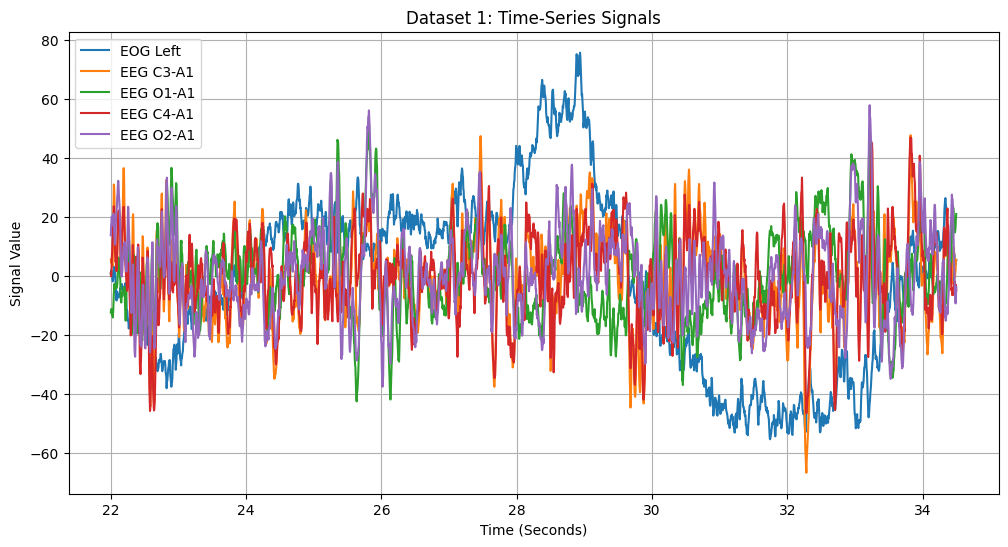

In [14]:
# Reattempt the plots
columns_to_plot_dataset1 = ["EOG Left", "EEG C3-A1", "EEG O1-A1", "EEG C4-A1", "EEG O2-A1"]
plot_time_series(df1, columns_to_plot_dataset1, "Dataset 1: Time-Series Signals")


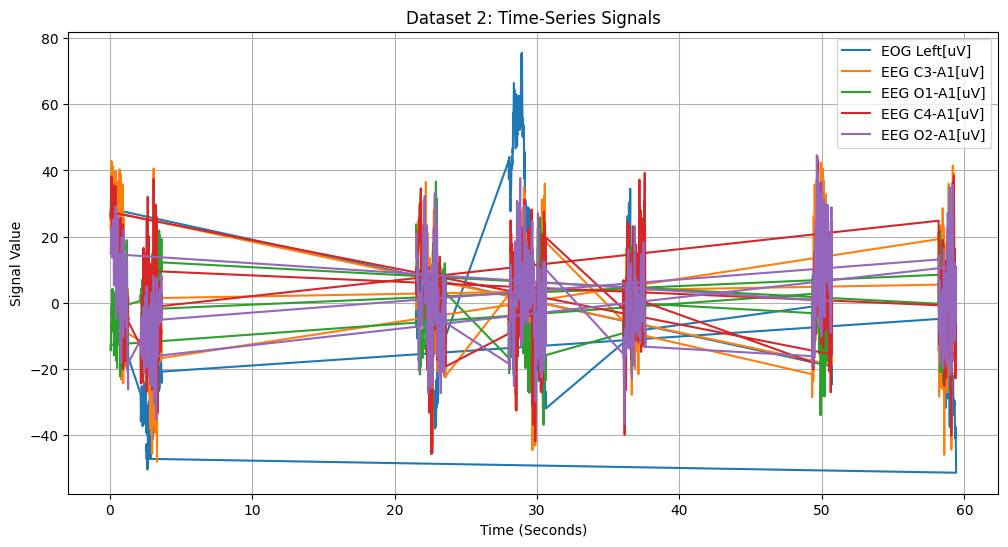

In [15]:
columns_to_plot_dataset2 = ["EOG Left[uV]", "EEG C3-A1[uV]", "EEG O1-A1[uV]", "EEG C4-A1[uV]", "EEG O2-A1[uV]"]
plot_time_series(df2, columns_to_plot_dataset2, "Dataset 2: Time-Series Signals")

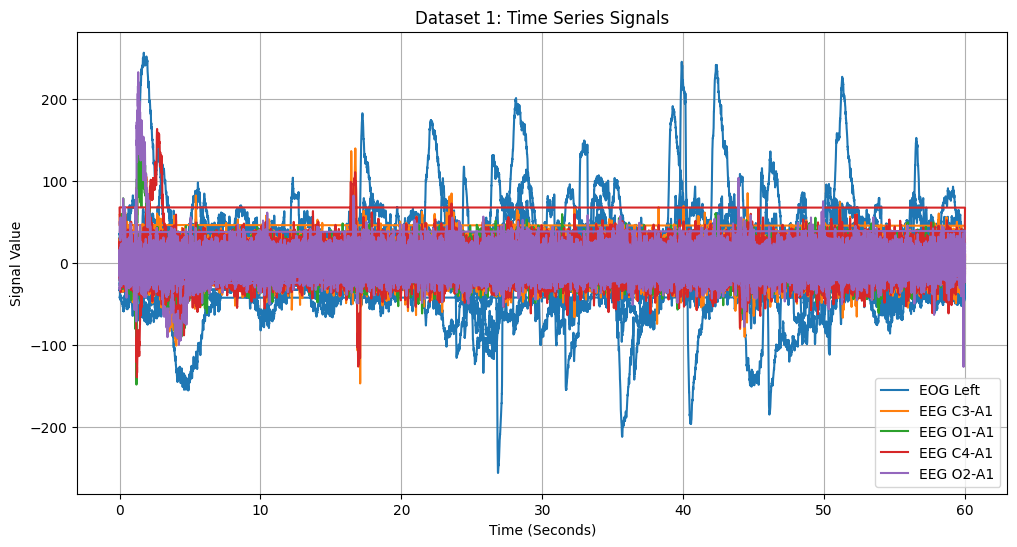

In [16]:
# Time series of signals for both datasets
def plot_all(df, columns, title, time_col="SS"):
    plt.figure(figsize=(12, 6))
    for col in columns:
        plt.plot(df[time_col], df[col], label=col)  # Plot entire dataset
    plt.title(title)
    plt.xlabel("Time (Seconds)")
    plt.ylabel("Signal Value")
    plt.legend()
    plt.grid()
    plt.show()

plot_all(df1, columns_to_plot_dataset1, "Dataset 1: Time Series Signals")

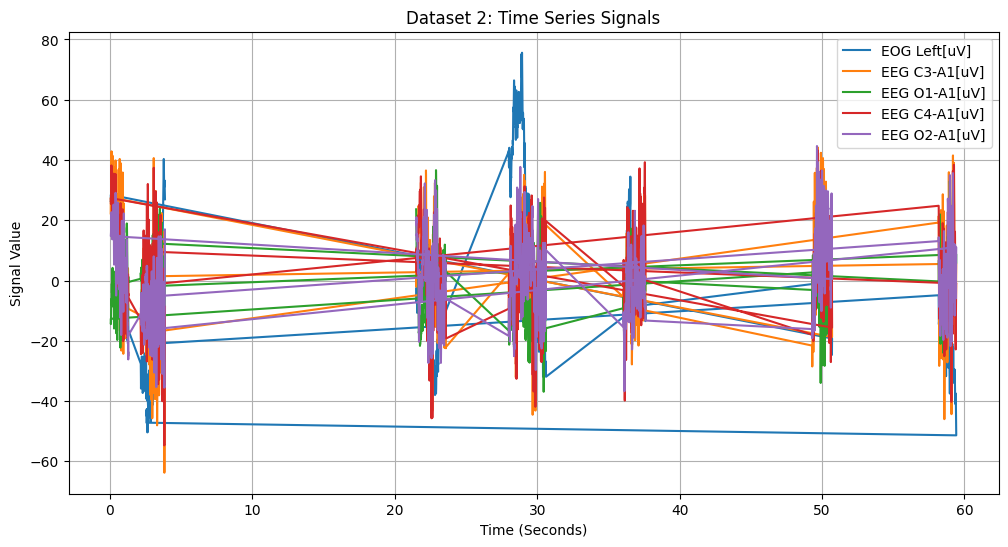

In [17]:
plot_all(df2, columns_to_plot_dataset2, "Dataset 2: Time Series Signals")

In [18]:
df2.columns = ['Date', 'HH', 'MM', 'SS', 'EOG Left', 'EEG C3-A1', 'EEG O1-A1', 'EEG C4-A1', 'EEG O2-A1']
#renaming columns for combining both

### For spindle detection, the date likely doesn't impact the classification.
### We will drop the date column as only the time is impactful

In [20]:
df1= df1.drop(columns=['Date'])
df2 = df2.drop(columns=['Date'])

In [21]:
df1

,HH,MM,SS,EOG Left,EEG C3-A1,EEG O1-A1,EEG C4-A1,EEG O2-A1
0,1,27,22.000,7.812500e-01,5.566406,-12.402344,0.976562,13.769531
1,1,27,22.005,1.953125e+00,4.785156,-11.230469,-0.097656,17.089844
2,1,27,22.010,-1.670000e-14,4.296875,-11.230469,0.976562,17.968750
3,1,27,22.015,7.812500e-01,4.785156,-12.011719,6.347656,20.117188
4,1,27,22.020,2.929688e-01,4.101562,-13.183594,8.105469,17.382812
...,...,...,...,...,...,...,...,...
248435,1,48,4.175,-2.246094e+01,-21.386719,21.777344,-21.484375,21.679688
248436,1,48,4.180,-2.070312e+01,-21.972656,18.261719,-19.433594,19.921875
248437,1,48,4.185,-2.050781e+01,-21.093750,14.648438,-17.773438,18.945312
248438,1,48,4.190,-1.806641e+01,-14.941406,12.109375,-9.765625,17.480469


In [22]:
df2

,HH,MM,SS,EOG Left,EEG C3-A1,EEG O1-A1,EEG C4-A1,EEG O2-A1
0,1,27,21.500,-7.128906,2.050781,23.632812,3.027344,18.457031
1,1,27,21.505,-6.640625,-2.050781,19.433594,2.832031,19.726562
2,1,27,21.510,-6.347656,-1.855469,17.285156,4.101562,19.335938
3,1,27,21.515,-7.324219,-1.660156,16.894531,5.566406,19.238281
4,1,27,21.520,-5.664063,-0.488281,16.796875,7.421875,20.996094
...,...,...,...,...,...,...,...,...
2593,1,48,3.845,29.296875,-35.839844,-1.757813,-30.273438,6.250000
2594,1,48,3.850,28.417969,-27.734375,3.515625,-23.242188,14.062500
2595,1,48,3.855,27.441406,-20.898438,9.277344,-17.382812,16.894531
2596,1,48,3.860,27.050781,-16.992188,9.765625,-11.425781,16.992188


In [23]:
# Combine datasets
data = pd.concat([df1, df2], ignore_index=True)

In [24]:
data

,HH,MM,SS,EOG Left,EEG C3-A1,EEG O1-A1,EEG C4-A1,EEG O2-A1
0,1,27,22.000,7.812500e-01,5.566406,-12.402344,0.976562,13.769531
1,1,27,22.005,1.953125e+00,4.785156,-11.230469,-0.097656,17.089844
2,1,27,22.010,-1.670000e-14,4.296875,-11.230469,0.976562,17.968750
3,1,27,22.015,7.812500e-01,4.785156,-12.011719,6.347656,20.117188
4,1,27,22.020,2.929688e-01,4.101562,-13.183594,8.105469,17.382812
...,...,...,...,...,...,...,...,...
251033,1,48,3.845,2.929688e+01,-35.839844,-1.757813,-30.273438,6.250000
251034,1,48,3.850,2.841797e+01,-27.734375,3.515625,-23.242188,14.062500
251035,1,48,3.855,2.744141e+01,-20.898438,9.277344,-17.382812,16.894531
251036,1,48,3.860,2.705078e+01,-16.992188,9.765625,-11.425781,16.992188


## Now, let us proceeed with data normalization, which will make it easier for us to train the neural network

In [26]:
# Normalize the EEG and EOG values
from sklearn.preprocessing import StandardScaler

In [27]:
scaler = StandardScaler()
signal_columns = ['EOG Left', 'EEG C3-A1', 'EEG O1-A1', 'EEG C4-A1', 'EEG O2-A1']
data[signal_columns] = scaler.fit_transform(data[signal_columns])

In [28]:
# Add a placeholder label column for spindle detection
data['Label'] = np.nan  # Placeholder, update with 1 for spindles and 0 for theta waves

In [29]:
data

,HH,MM,SS,EOG Left,EEG C3-A1,EEG O1-A1,EEG C4-A1,EEG O2-A1,Label
0,1,27,22.000,0.026079,0.386671,-1.061947,0.068428,1.093215,NaN
1,1,27,22.005,0.062410,0.332247,-0.961613,-0.007893,1.356931,NaN
2,1,27,22.010,0.001858,0.298231,-0.961613,0.068428,1.426738,NaN
3,1,27,22.015,0.026079,0.332247,-1.028502,0.450035,1.597378,NaN
4,1,27,22.020,0.010941,0.284625,-1.128836,0.574925,1.380200,NaN
...,...,...,...,...,...,...,...,...,...
251033,1,48,3.845,0.910138,-2.497833,-0.150580,-2.151832,0.495976,NaN
251034,1,48,3.850,0.882889,-1.933178,0.300923,-1.652274,1.116484,NaN
251035,1,48,3.855,0.852613,-1.456963,0.794231,-1.235975,1.341418,NaN
251036,1,48,3.860,0.840503,-1.184840,0.836037,-0.812738,1.349175,NaN


In [30]:
# can be done if needed for modelling:
# data['Label'] = data['Label'].fillna(0)

In [31]:
# Save the combined dataset to inspect later
data.to_csv('final_dataset.csv', index=False)

# Now that we have the final dataset, we can proceed for Modelling 